---

### 🧠 Base Predictive Model — 2D Advection–Diffusion Simulation

The predictive model implemented in this notebook is a **numerical simulation of a simplified two-dimensional fluid mechanics system**.
It is designed to be sufficiently complex to reproduce essential physical behaviors (such as advection, diffusion, and pressure–temperature coupling), while remaining computationally efficient for repeated runs during the evaluation of **data assimilation (DA)** methods.

---

#### ⚙️ Spatial Domain and Boundary Conditions

* **Spatial domain:** ($x, y \in [0, 1]$)
* **Spatial resolution:** user-defined

  * Typical setup: ($25 \times 25$)
  * (A higher-resolution “truth” field can optionally be used for validation)
* **Boundary conditions:** Dirichlet and Neumann (non-periodic)

  * Inlet and outlet velocities are fixed.
  * Pressure gradients are prescribed through an *adverse pressure field* term.
* **Simulation duration:** fixed number of time steps determined by a CFL-based criterion.

---

#### 🔄 Simulated Variables

* ($T(x, y, t)$): Temperature
* ($p(x, y, t)$): Pressure
* ($\tau(x, y, t)$): Auxiliary variable (e.g., local shear or stress)
* ($u(x, y, t), v(x, y, t)$): Velocity components (2D flow field)

Each variable evolves in time according to advection–diffusion-type dynamics, coupled through pressure and viscous heating terms.

---

#### 🧮 Governing Equations (general form)
$$
\frac{\partial f}{\partial t} + u \frac{\partial f}{\partial x} + v \frac{\partial f}{\partial y} = \alpha \nabla^2 f + S_f
$$

where ($f \in {T, p, \tau}$), ($\alpha$) is the diffusion coefficient, and ($S_f$) represents a source term (including viscous heating or imposed pressure effects).

---

#### 💻 Numerical Discretization

* Explicit **finite-difference scheme** for time integration.
* Spatial discretization: ($\Delta x = \Delta y = 1/(N-1)$).
* Time step determined from a simple **CFL-like condition**.
* Pressure correction performed via **iterative relaxation** and addition of a **prescribed adverse pressure gradient**.
* Boundary conditions applied after each update for stability and physical consistency.

---

#### 🧩 Data Assimilation Framework

The simulation supports **optional data assimilation** during runtime via a flexible interface:

* Observations are passed as a dictionary ({t: \text{observations}}).
* Any DA method (e.g., Nudging, Kalman Filter, EnKF, 3D-Var, 4D-Var) can be externally connected through the argument `metodo_asimilacion`.
* The assimilated variables (e.g., `['T']`, `['p']`, or both) are specified by `variables_asimilar`.

This structure allows systematic comparison of DA algorithms under identical physical and numerical conditions.

---

#### 🎯 Model Purpose

The model serves as a **controlled testbed** to evaluate and compare data assimilation approaches in a reproducible environment.
It allows assessment of:

* **Accuracy**, via root-mean-square error (RMSE) against a reference solution,
* **Computational cost**, through measured assimilation time,
* **Sensitivity**, to observation density, noise, and variable coupling.

All historical fields ((u, v, p, T, \tau)) are stored in memory and returned as Python objects for visualization or further analysis (saving to disk is optional).

---


In [1]:
import sys
import matplotlib.pyplot as plt
import numpy as np
from typing import Optional, Dict, Tuple
import os
import pickle
from numba import njit, prange
from matplotlib.animation import FuncAnimation,FFMpegWriter, PillowWriter
from IPython.display import HTML
from scipy.interpolate import RegularGridInterpolator
import time
import pandas as pd
from copy import deepcopy
import seaborn as sns
from numba import set_num_threads
from itertools import product
from tqdm import tqdm
from collections import defaultdict
import copy
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 20,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
    # No uses font.weight aquí: no afecta cuando usas LaTeX
})


In [4]:
def actualizacion_campos(
    # --- Física / dominios ---
    presion_adversa: float,
    u_old: np.ndarray, v_old: np.ndarray, p_old: np.ndarray, T_old: np.ndarray,
    u_star: np.ndarray, v_star: np.ndarray, p_star: np.ndarray, T_star: np.ndarray,
    Re: float, Pr: float, Ec: float, Eu: float,
    dt_star: float, dx_star: float, dy_star: float, nx: int, ny: int,
    n_press_iters: int = 20,
    # --- Observaciones pared (y=0) ---
    obs_T_wall: Optional[np.ndarray] = None,   # shape (nx,) o None
    obs_p_wall: Optional[np.ndarray] = None,   # shape (nx,) o None
    # --- Método secuencial ---
    seq_method: str = "none",                  # "none" | "nudging" | "kf"
    method_kwargs: Optional[Dict] = None,      # hiperparámetros del método
    seq_state: Optional[Dict] = None           # estado persistente (KF)
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, Dict]:
    """
    Un paso CPU del sistema acoplado u,v,p,T con DA secuencial en la pared (y=0).
    Estructura A→G:
      A) Inyección en pared (T_old y p Dirichlet en Jacobi) según método
      B) Predictor u,v con (u_old,v_old,p_old,T_old)
      C) Jacobi para p con Dirichlet opcional en y=0
      D) Gradiente de presión adverso
      E) Proyección de momento usando ∇p_star
      F) Paso de temperatura usando T_old corregido en pared
      G) Condiciones de contorno (y paredes; x abiertas)
    """
    method_kwargs = method_kwargs or {}
    seq_state = {} if seq_state is None else dict(seq_state)

    # ============================
    # Selección de método (pared)
    # ============================
    inj_T = None
    inj_p = None
    alpha_T = 0.0
    alpha_p = 0.0

    if seq_method == "none":
        pass

    elif seq_method == "nudging":
        alpha = float(method_kwargs.get("alpha", 0.2))
        if obs_T_wall is not None:
            inj_T = obs_T_wall; alpha_T = alpha
        if obs_p_wall is not None:
            inj_p = obs_p_wall; alpha_p = alpha

    elif seq_method == "kf":
        # Hiperparámetros KF (ruido observación y proceso en la pared)
        R_T = float(method_kwargs.get("R_T", 1e-2))
        R_p = float(method_kwargs.get("R_p", 1e-2))
        Q_T = float(method_kwargs.get("Q_T", 1e-4))
        Q_p = float(method_kwargs.get("Q_p", 1e-4))

        # Estado por columna en pared (medias y varianzas)
        xT = seq_state.get("xT", T_old[0, :].copy())
        PT = seq_state.get("PT", np.ones(nx) * 0.1)
        xp = seq_state.get("xp", p_star[0, :].copy())
        Pp = seq_state.get("Pp", np.ones(nx) * 0.1)

        # Predicción (random walk en pared; H=1)
        xT_pred = T_old[0, :].copy()
        PT_pred = PT + Q_T
        xp_pred = p_star[0, :].copy()
        Pp_pred = Pp + Q_p

        # Actualización por campo (si hay obs)
        if obs_T_wall is not None:
            Kt = PT_pred / (PT_pred + R_T)
            xT = xT_pred + Kt * (obs_T_wall - xT_pred)
            PT = (1.0 - Kt) * PT_pred
            inj_T = xT; alpha_T = 1.0
        else:
            xT, PT = xT_pred, PT_pred

        if obs_p_wall is not None:
            Kp = Pp_pred / (Pp_pred + R_p)
            xp = xp_pred + Kp * (obs_p_wall - xp_pred)
            Pp = (1.0 - Kp) * Pp_pred
            inj_p = xp; alpha_p = 1.0
        else:
            xp, Pp = xp_pred, Pp_pred

        # Guardar estado
        seq_state["xT"], seq_state["PT"] = xT, PT
        seq_state["xp"], seq_state["Pp"] = xp, Pp

    else:
        raise ValueError(f"Unknown seq_method='{seq_method}' (use 'none' | 'nudging' | 'kf').")

    # ============================
    # A → G
    # ============================
    inv_dx  = 1.0 / dx_star
    inv_dy  = 1.0 / dy_star
    inv_dx2 = inv_dx * inv_dx
    inv_dy2 = inv_dy * inv_dy
    inv_Re  = 1.0 / Re
    inv_RePr = 1.0 / (Re * Pr)

    # A) Inyección pared (T_old y p objetivo para Dirichlet en Jacobi)
    if inj_T is not None and alpha_T > 0.0:
        T_old[0, :] = (1.0 - alpha_T) * T_old[0, :] + alpha_T * inj_T

    use_p_dirichlet = (inj_p is not None and alpha_p > 0.0)
    if use_p_dirichlet:
        p_wall_target = (1.0 - alpha_p) * p_star[0, :] + alpha_p * inj_p

    # B) Predictor u, v
    for i in range(1, ny - 1):
        u_i, u_ip1, u_im1 = u_old[i, :], u_old[i + 1, :], u_old[i - 1, :]
        v_i, v_ip1, v_im1 = v_old[i, :], v_old[i + 1, :], v_old[i - 1, :]
        p_ip1, p_im1 = p_old[i + 1, :], p_old[i - 1, :]
        for j in range(1, nx - 1):
            conv_u_x = u_i[j] * (u_i[j + 1] - u_i[j - 1]) * 0.5 * inv_dx
            conv_u_y = v_i[j] * (u_ip1[j] - u_im1[j]) * 0.5 * inv_dy
            diff_u_x = (u_i[j + 1] - 2.0*u_i[j] + u_i[j - 1]) * inv_dx2
            diff_u_y = (u_ip1[j] - 2.0*u_i[j] + u_im1[j]) * inv_dy2
            u_star[i, j] = u_old[i, j] + dt_star * (-conv_u_x - conv_u_y + inv_Re*(diff_u_x + diff_u_y))

            conv_v_x = u_i[j] * (v_i[j + 1] - v_i[j - 1]) * 0.5 * inv_dx
            conv_v_y = v_i[j] * (v_ip1[j] - v_im1[j]) * 0.5 * inv_dy
            diff_v_x = (v_i[j + 1] - 2.0*v_i[j] + v_i[j - 1]) * inv_dx2
            diff_v_y = (v_ip1[j] - 2.0*v_i[j] + v_im1[j]) * inv_dy2
            grad_p_y = (p_ip1[j] - p_im1[j]) * 0.5 * inv_dy
            v_star[i, j] = v_old[i, j] + dt_star * (-conv_v_x - conv_v_y - Eu*grad_p_y + inv_Re*(diff_v_x + diff_v_y))

    # C) Jacobi para presión (Dirichlet en y=0 si hay obs de p)
    p_buf = p_star.copy()
    coeff_div = (dx_star * dy_star) / (2.0 * (dx_star*dx_star + dy_star*dy_star))
    for _ in range(n_press_iters):
        for i in range(1, ny - 1):
            for j in range(1, nx - 1):
                div = (u_star[i, j + 1] - u_star[i, j - 1]) * 0.5 * inv_dx + \
                      (v_star[i + 1, j] - v_star[i - 1, j]) * 0.5 * inv_dy
                p_buf[i, j] = 0.25 * (
                    p_star[i + 1, j] + p_star[i - 1, j] +
                    p_star[i, j + 1] + p_star[i, j - 1]
                ) - coeff_div * div

        # x abiertas (Neumann)
        p_buf[:,  0] = p_buf[:,  1]
        p_buf[:, -1] = p_buf[:, -2]
        # y=top (Neumann)
        p_buf[-1, :] = p_buf[-2, :]
        # y=bottom: Dirichlet si hay obs, si no Neumann
        if use_p_dirichlet:
            p_buf[0, :] = p_wall_target
        else:
            p_buf[0, :] = p_buf[1, :]

        p_star, p_buf = p_buf, p_star

    # D) Gradiente de presión adverso (a lo largo de x)
    for j in range(nx):
        x = j * dx_star
        base = 0.01 if x <= 0.3 else 0.0
        adv  = 0.0  if x <= 0.3 else presion_adversa * (x - 0.3)
        p_star[:, j] += (base + adv)

    # E) Proyección de momento (∇p_star)
    inv_dx = 1.0 / dx_star
    inv_dy = 1.0 / dy_star
    for i in range(1, ny - 1):
        for j in range(1, nx - 1):
            du_p = (p_star[i, j + 1] - p_star[i, j - 1]) * 0.5 * inv_dx
            dv_p = (p_star[i + 1, j] - p_star[i - 1, j]) * 0.5 * inv_dy
            u_star[i, j] -= dt_star * Eu * du_p
            v_star[i, j] -= dt_star * Eu * dv_p

    # F) Temperatura (con T_old pared ya corregido)
    for i in range(1, ny - 1):
        for j in range(1, nx - 1):
            conv_T_x = u_star[i, j] * (T_old[i, j + 1] - T_old[i, j - 1]) * 0.5 * inv_dx
            conv_T_y = v_star[i, j] * (T_old[i + 1, j] - T_old[i - 1, j]) * 0.5 * inv_dy
            diff_T_x = (T_old[i, j + 1] - 2.0*T_old[i, j] + T_old[i, j - 1]) * inv_dx2
            diff_T_y = (T_old[i + 1, j] - 2.0*T_old[i, j] + T_old[i - 1, j]) * inv_dy2

            Sxx = (u_star[i, j + 1] - u_star[i, j - 1]) * 0.5 * inv_dx
            Syy = (v_star[i + 1, j] - v_star[i - 1, j]) * 0.5 * inv_dy
            Sxy = 0.5 * ((u_star[i + 1, j] - u_star[i - 1, j]) * 0.5 * inv_dy +
                         (v_star[i, j + 1] - v_star[i, j - 1]) * 0.5 * inv_dx)
            viscous_heating = (Ec * inv_Re) * (2.0 * (Sxx*Sxx + Syy*Syy) + 4.0 * Sxy*Sxy)

            T_star[i, j] = T_old[i, j] + dt_star * (
                -conv_T_x - conv_T_y + inv_RePr * (diff_T_x + diff_T_y) + viscous_heating
            )

    # G) Condiciones de contorno (y paredes; x abiertas)
    v_star[0, :]  = 0.0
    v_star[-1, :] = 0.0
    u_star[0, :]  = -0.5
    u_star[-1, :] =  1.0
    u_star[:,  0] = u_star[:,  1];  u_star[:, -1] = u_star[:, -2]
    v_star[:,  0] = v_star[:,  1];  v_star[:, -1] = v_star[:, -2]
    T_star[:,  0] = T_star[:,  1];  T_star[:, -1] = T_star[:, -2]
    p_star[:,  0] = p_star[:,  1];  p_star[:, -1] = p_star[:, -2]

    return u_star, v_star, p_star, T_star, seq_state


In [5]:
import time
import numpy as np

def simulacion_general(
    nx=25, ny=25,
    presion_adversa=0.3,
    Re=20.0, Pr=10.0, Ec=0.1, Eu=1.0,
    # --- Observaciones y método secuencial ---
    observaciones_dict=None,               # dict: step -> {"T": (nx,), "p": (nx,)}
    seq_method: str = "none",              # "none" | "nudging" | "kf"
    method_kwargs: dict = None,            # {"alpha":...} o {"R_T":...,"R_p":...,"Q_T":...,"Q_p":...}
    # --- Salida / almacenamiento ---
    N_FRAMES=300
):
    """
    2D advection–diffusion acoplada (u, v, p, T) con DA secuencial opcional en la pared (y=0).
    - Observaciones de pared (y=0) para T y/o p.
    - seq_method: "none" (sin DA), "nudging" (un único alpha), "kf" (KF escalar por columna).
    """
    method_kwargs = {} if method_kwargs is None else dict(method_kwargs)
    observaciones_dict = observaciones_dict or {}

    # --- Dominio y pasos ---
    Lx_star = Ly_star = 1.0
    dx_star = Lx_star / (nx - 1)
    dy_star = Ly_star / (ny - 1)
    dt_cfl = 0.008 * dx_star / 1.0
    nt = int(np.ceil(2.0 / dt_cfl))
    dt_star = 1.0 / nt

    save_interval = max(1, nt // max(1, N_FRAMES))
    save_times = set(range(0, nt, save_interval)); save_times.add(nt - 1)

    x_star = np.linspace(0.0, Lx_star, nx)
    y_star = np.linspace(0.0, Ly_star, ny)
    X_star, Y_star = np.meshgrid(x_star, y_star)

    # --- Inicialización de campos ---
    u_star = np.ones((ny, nx))
    v_star = np.zeros((ny, nx))
    p_star = np.zeros((ny, nx))
    T_star = np.zeros((ny, nx))

    # Condiciones de frontera iniciales en y
    u_star[0, :]  = -0.5   # pared (y=0)
    u_star[-1, :] =  1.0   # free-stream (y=1)

    # Buffers previos
    u_old = u_star.copy()
    v_old = v_star.copy()
    p_old = p_star.copy()
    T_old = T_star.copy()

    # Históricos
    u_hist, v_hist, p_hist, T_hist = [], [], [], []
    total_assim_time = 0.0

    # Estado secuencial persistente (solo para KF)
    seq_state = {}

    for n in range(nt):
        # Preparar observaciones de pared (si existen en este paso)
        obs_pack = observaciones_dict.get(n, {})
        obs_T_wall = obs_pack.get("T", None)  # None o array (nx,)
        obs_p_wall = obs_pack.get("p", None)  # None o array (nx,)

        # Avance temporal: copiar a buffers
        u_old[:, :], v_old[:, :], p_old[:, :], T_old[:, :] = u_star, v_star, p_star, T_star

        t0 = time.time()

        # Un paso con/ sin DA secuencial, inyectando obs en pared
        u_star, v_star, p_star, T_star, seq_state = actualizacion_campos(
            presion_adversa,
            u_old, v_old, p_old, T_old,
            u_star, v_star, p_star, T_star,
            Re, Pr, Ec, Eu,
            dt_star, dx_star, dy_star, nx, ny,
            n_press_iters=20,
            obs_T_wall=obs_T_wall,
            obs_p_wall=obs_p_wall,
            seq_method=seq_method,           # "none" | "nudging" | "kf"
            method_kwargs=method_kwargs,
            seq_state=seq_state
        )

        total_assim_time += (time.time() - t0)

        # Guardado
        if n in save_times:
            u_hist.append(u_star.copy())
            v_hist.append(v_star.copy())
            p_hist.append(p_star.copy())
            T_hist.append(T_star.copy())

    print(f"\n✅ Simulation completed (CPU)\n"
          f" - Re={Re}, Pr={Pr}, Ec={Ec}, Eu={Eu}\n"
          f" - Method: {seq_method}, Assim time: {total_assim_time:.3f}s")

    return {
        "u_history": u_hist,
        "v_history": v_hist,
        "p_history": p_hist,
        "T_history": T_hist,
        "params": {
            "nx": nx, "ny": ny, "dt_star": dt_star, "nt": nt,
            "presion_adversa": presion_adversa,
            "Re": Re, "Pr": Pr, "Ec": Ec, "Eu": Eu,
            "seq_method": seq_method,
            "method_kwargs": method_kwargs
        },
        "X_star": X_star, "Y_star": Y_star,
        "asimilacion_time": total_assim_time
    }



✅ Simulation completed (CPU)
 - Re=100.0, Pr=7.0, Ec=0.05, Eu=1.0
 - Method: none, Assim time: 58.639s
✅ Simulación completada sin DA.
- Campos guardados: 301 instantes
- Dimensiones del dominio: (25, 25)
- Re = 100.0, Pr = 7.0, Ec = 0.05, Eu = 1.0


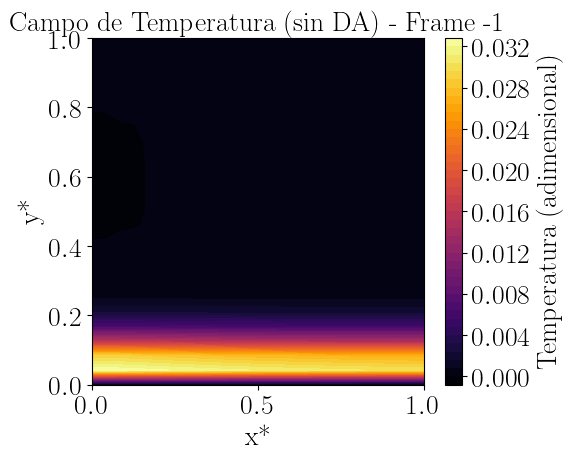

In [6]:
import numpy as np

# --- PARÁMETROS DE SIMULACIÓN ---
nx, ny = 25, 25               # resolución espacial
Re, Pr, Ec, Eu = 100.0, 7.0, 0.05, 1.0
presion_adversa = 0.3
N_FRAMES = 300                # número de pasos guardados

# --- EJECUTAR SIMULACIÓN SIN ASIMILACIÓN ---
resultados = simulacion_general(
    nx=nx, ny=ny,
    presion_adversa=presion_adversa,
    Re=Re, Pr=Pr, Ec=Ec, Eu=Eu,
    observaciones_dict=None,       # 🔹 sin observaciones
    seq_method="none",             # 🔹 sin DA
    method_kwargs={},              # 🔹 sin hiperparámetros
    N_FRAMES=N_FRAMES
)

# --- EXTRAER RESULTADOS ---
u_hist = np.array(resultados["u_history"])
v_hist = np.array(resultados["v_history"])
p_hist = np.array(resultados["p_history"])
T_hist = np.array(resultados["T_history"])
X_star = resultados["X_star"]
Y_star = resultados["Y_star"]

print(f"✅ Simulación completada sin DA.")
print(f"- Campos guardados: {len(u_hist)} instantes")
print(f"- Dimensiones del dominio: ({ny}, {nx})")
print(f"- Re = {Re}, Pr = {Pr}, Ec = {Ec}, Eu = {Eu}")

# --- VISUALIZAR UN INSTANTE ---
import matplotlib.pyplot as plt

idx = -1   # último frame guardado
plt.figure(figsize=(6,5))
cp = plt.contourf(X_star, Y_star, T_hist[idx], levels=40, cmap='inferno')
plt.colorbar(cp, label="Temperatura (adimensional)")
plt.xlabel("x*")
plt.ylabel("y*")
plt.title(f"Campo de Temperatura (sin DA) - Frame {idx}")
plt.tight_layout()
plt.show()
